**HW 3**

Begin Imports

In [669]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

**Problem 1**

**Diabetes Data Import**

In [670]:
#input dara link
url = 'https://raw.githubusercontent.com/iperezv-cpu/ML/refs/heads/main/diabetes.csv'

df = pd.read_csv(url)

# Display the first 10 rows of the DataFrame
df.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [671]:
df.shape


(768, 9)

Problem 1 — Diabetes Classification
    
*   Steps
    1. Import/load diabetes data
    2. Clean/inspect data
    3. Define X and y
    4. 80/20 split
    5. Scale data
    6. Train logistic regression
    7. Plot loss and accuracy
    8. Evaluate metrics
    9. Confusion matrix





**Define X and Y**

In [672]:
X_Diabetes = df.drop("Outcome", axis=1)
y_Diabetes = df["Outcome"]

**80/20 Split**

In [673]:
#Now we’ll split our Data set into Training Data and Test Data. Training data will be used to train our
#Logistic model and Test data will be used to validate our model. We’ll use Sklearn to split our data. We’ll import  train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_Diabetes, y_Diabetes, test_size = 0.20, random_state = 0, stratify=y_Diabetes)

**Scaling Data**

In [674]:
#Now we’ll do feature scaling to scale our data between 0 and 1 to get better accuracy.
#Here Scaling is important because there is a huge difference between all the features
from sklearn.preprocessing import StandardScaler   #import

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

**Logistic Regression Training**

In [675]:
#Import LogisticRegression from sklearn.linear_model
#Make an instance classifier of the object LogisticRegression and give random_state =  0
#from sklearn.linear_model import LogisticRegression
#classifier = LogisticRegression(random_state=0)
#classifier.fit(X_train, Y_train)

In [676]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

iterations = 100

classifier = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=0
)

loss_history = []
accuracy_history = []

for i in range(iterations):

    classifier.partial_fit(X_train, Y_train,
        classes=np.array([0, 1])
    )
    # Probability predictions for calculating loss
    Y_prob = classifier.predict_proba(X_train)

    # Class predictions for calculating accuracy
    Y_train_pred = classifier.predict(X_train)

    # Save this iteration's results
    loss_history.append(
        log_loss(Y_train, Y_prob)
    )

    accuracy_history.append(
        accuracy_score(Y_train, Y_train_pred)
    )

In [677]:
Y_pred = classifier.predict(X_test)

In [678]:
Y_pred[0:9]

array([0, 0, 0, 0, 1, 0, 1, 0, 0])

In [679]:
#Using Confusion matrix we can get accuracy of our model.

from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(Y_test, Y_pred)
cnf_matrix

array([[88, 12],
       [25, 29]])

**Accuracy, Precision, Recall,and F1 Score**

In [680]:
#Let's evaluate the model using model evaluation metrics such as accuracy, precision, and recall.
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))
print("Precision:",metrics.precision_score(Y_test, Y_pred))
print("Recall:",metrics.recall_score(Y_test, Y_pred))
print("F1 Score:", metrics.f1_score(Y_test, Y_pred))

Accuracy: 0.7597402597402597
Precision: 0.7073170731707317
Recall: 0.5370370370370371
F1 Score: 0.6105263157894737


Text(0.5, 533.5555555555555, 'Predicted label')

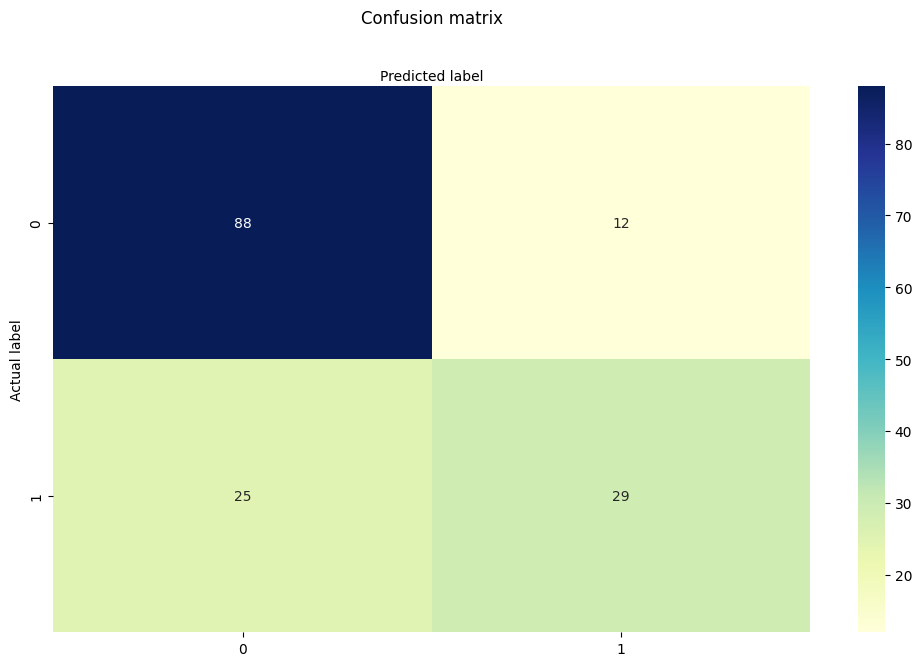

In [681]:
#Let's visualize the results of the model in the form of a co#nfusion matrix using matplotlib and seaborn.
#Here, you will visualize the confusion matrix using Heatmap.
import seaborn as sns
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

***Loss over Iterartion**

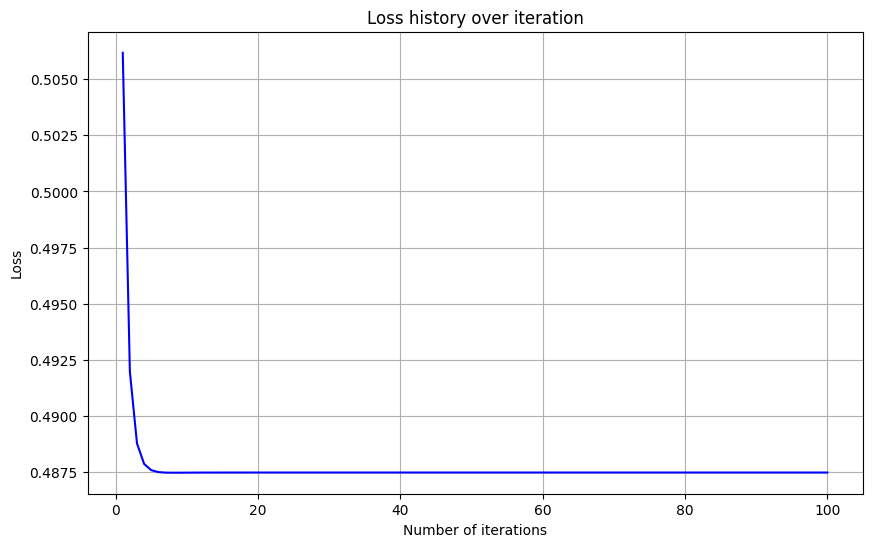

In [682]:
plt.plot(range(1, iterations + 1), loss_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Loss history over iteration')

# Show the plot
plt.show()

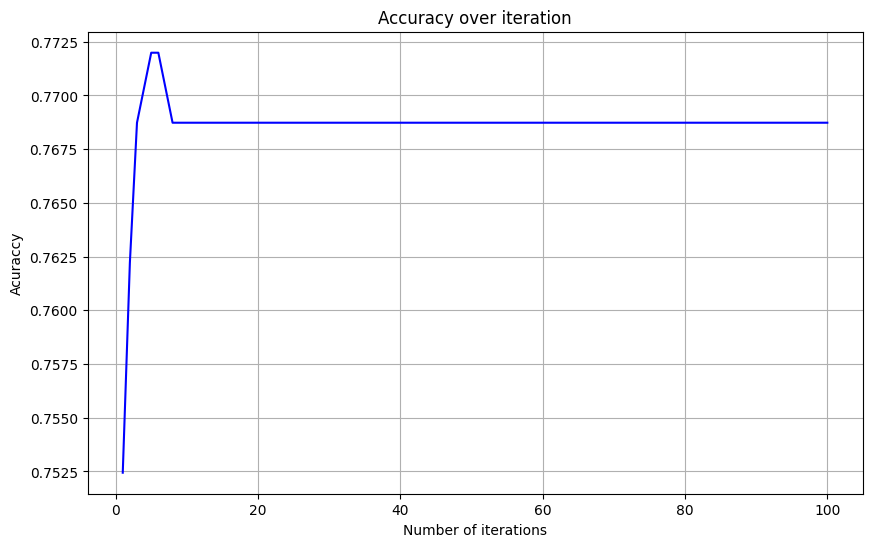

In [683]:
plt.plot(range(1, iterations + 1), accuracy_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Acuraccy')
plt.title('Accuracy over iteration')

# Show the plot
plt.show()

**Problem 2**

**Problem 2.1**

**Cancer Dataset**

In [684]:
#input dara link
url = 'https://raw.githubusercontent.com/iperezv-cpu/ML/refs/heads/main/Cancer.csv'

Cancer_Data = pd.read_csv(url)

# Display the first 10 rows of the DataFrame
Cancer_Data.head(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,NaN


In [685]:
Cancer_Data.shape


(569, 33)

In [686]:
#gets rid of the last column where everything is NaNa
Cancer_Data = Cancer_Data.drop(columns=[ "id", "Unnamed: 32"], errors="ignore")

In [687]:

Cancer_Data.shape

(569, 31)

In [688]:
Cancer_Data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Set Diagnoses as 0 and 1's**

In [689]:
# List of variables to map

varlist =  ['diagnosis']

# Defining the map function
def binary_map(x):
    return x.map({'M': 1, 'B': 0})

# Applying the function to the housing list
Cancer_Data[varlist] = Cancer_Data[varlist].apply(binary_map)
Cancer_Data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**X and Y defined**

In [690]:
X_Cancer = Cancer_Data.drop("diagnosis", axis=1)
y_Cancer = Cancer_Data["diagnosis"]

**80/20 Split**

In [691]:
#Now we’ll split our Data set into Training Data and Test Data. Training data will be used to train our
#Logistic model and Test data will be used to validate our model. We’ll use Sklearn to split our data. We’ll import  train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

X_train_Cancer, X_test_Cancer, Y_train_Cancer, Y_test_Cancer = train_test_split(X_Cancer, y_Cancer, test_size = 0.20, random_state = 0, stratify=y_Cancer)

**Scaling Data**

In [692]:
#Now we’ll do feature scaling to scale our data between 0 and 1 to get better accuracy.
#Here Scaling is important because there is a huge difference between all the features
from sklearn.preprocessing import StandardScaler   #import

sc_X_Cancer = StandardScaler()
X_train_Cancer = sc_X_Cancer.fit_transform(X_train_Cancer)
X_test_Cancer = sc_X_Cancer.transform(X_test_Cancer)

**Regession**

In [693]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

iterations = 100

classifier_Cancer = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=0
)

loss_history_Cancer = []
accuracy_history_Cancer = []

for i in range(iterations):

    classifier_Cancer.partial_fit(X_train_Cancer, Y_train_Cancer,
        classes=np.array([0, 1])
    )

    # Probability predictions for calculating loss
    Y_prob_Cancer = classifier_Cancer.predict_proba(X_train_Cancer)

    # Class predictions for calculating accuracy
    Y_train_pred_Cancer = classifier_Cancer.predict(X_train_Cancer)

    # Save this iteration's results
    loss_history_Cancer.append(
        log_loss(Y_train_Cancer, Y_prob_Cancer)
    )

    accuracy_history_Cancer.append(
        accuracy_score(Y_train_Cancer, Y_train_pred_Cancer)
    )

    #penalty=None

In [694]:
Y_pred_Cancer = classifier_Cancer.predict(X_test_Cancer)

In [695]:
Y_pred_Cancer [0:9]

array([0, 0, 0, 0, 0, 1, 0, 0, 1])

In [696]:
#Using Confusion matrix we can get accuracy of our model.

from sklearn.metrics import confusion_matrix
cnf_matrix_Cancer = confusion_matrix(Y_test_Cancer, Y_pred_Cancer)
cnf_matrix_Cancer

array([[69,  3],
       [ 2, 40]])

**Accuracy, Precision, Recall,and F1 Score**

In [697]:
#Let's evaluate the model using model evaluation metrics such as accuracy, precision, and recall.
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(Y_test_Cancer, Y_pred_Cancer))
print("Precision:",metrics.precision_score(Y_test_Cancer, Y_pred_Cancer))
print("Recall:",metrics.recall_score(Y_test_Cancer, Y_pred_Cancer))
print("F1 Score:", metrics.f1_score(Y_test_Cancer, Y_pred_Cancer))

Accuracy: 0.956140350877193
Precision: 0.9302325581395349
Recall: 0.9523809523809523
F1 Score: 0.9411764705882353


**Confusion Matrix**

Text(0.5, 533.5555555555555, 'Predicted Diagnosis')

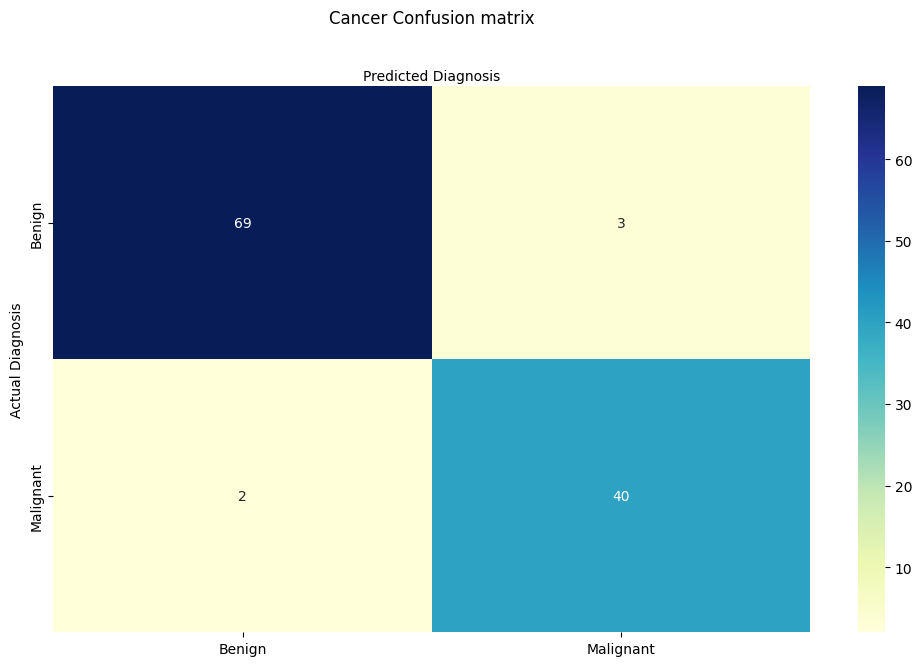

In [698]:
#Let's visualize the results of the model in the form of a co#nfusion matrix using matplotlib
#Here, you will visualize the confusion matrix using Heatmap.
import seaborn as sns

class_names_Cancer=['Benign','Malignant'] # name  of classes  0---> Benign, 1---> Malignant

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names_Cancer))
plt.xticks(tick_marks, class_names_Cancer)
plt.yticks(tick_marks, class_names_Cancer)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_Cancer), annot=True, cmap="YlGnBu" ,fmt='g',xticklabels=class_names_Cancer,
    yticklabels=class_names_Cancer)

ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Cancer Confusion matrix', y=1.1)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')

**Loss over Iteration**

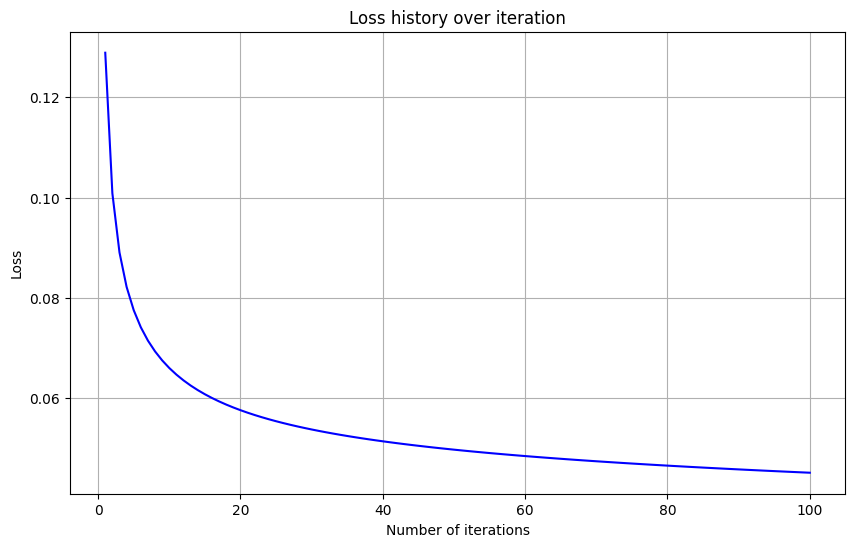

In [699]:
plt.plot(range(1, iterations + 1), loss_history_Cancer, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Loss history over iteration')
# Show the plot
plt.show()

**Acuraccy of Iteration**

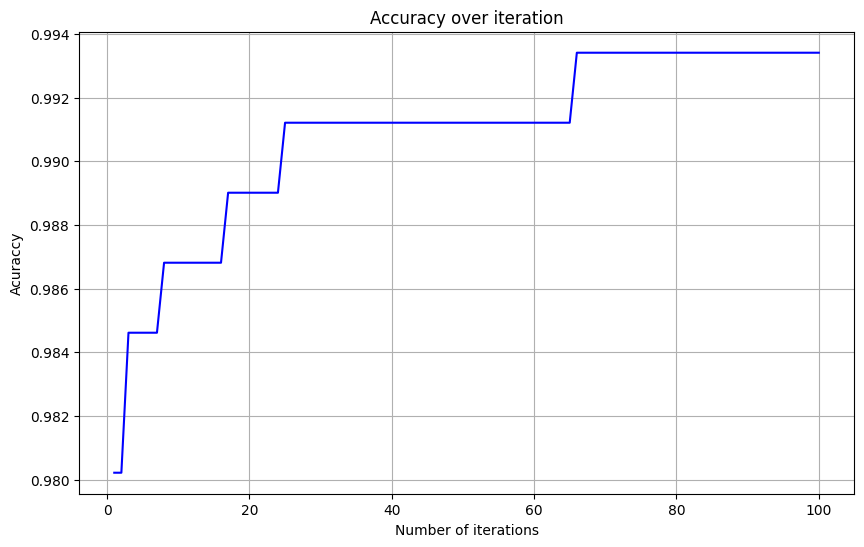

In [700]:
plt.plot(range(1, iterations + 1), accuracy_history_Cancer, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Number of iterations')
plt.ylabel('Acuraccy')
plt.title('Accuracy over iteration')
# Show the plot
plt.show()

**Problem 2.2**

How about adding a weight penalty here, considering the number of parameters. Add the weight penalty and repeat the training and report the results.

**Regression for problem 2.2**

In [701]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

iterations = 100

classifier_Cancer_Penalty = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    penalty="l2", alpha=0.001, random_state=0


)

loss_history_Cancer_Penalty = []
accuracy_history_Cancer_Penalty = []

for i in range(iterations):

    classifier_Cancer_Penalty.partial_fit(X_train_Cancer, Y_train_Cancer,
        classes=np.array([0, 1])
    )

    # Probability predictions for calculating loss
    Y_prob_Cancer_Penalty = classifier_Cancer_Penalty.predict_proba(X_train_Cancer)

    # Class predictions for calculating accuracy
    Y_train_pred_Cancer_Penalty = classifier_Cancer_Penalty.predict(X_train_Cancer)

    # Save this iteration's results
    loss_history_Cancer_Penalty.append(
        log_loss(Y_train_Cancer, Y_prob_Cancer_Penalty)
    )

    accuracy_history_Cancer_Penalty.append(
        accuracy_score(Y_train_Cancer, Y_train_pred_Cancer_Penalty)
    )

    penalty=12

In [702]:
Y_pred_Cancer_Penalty = classifier_Cancer_Penalty.predict(X_test_Cancer)

In [703]:
Y_pred_Cancer_Penalty[0:9]

array([0, 0, 0, 0, 0, 1, 0, 0, 1])

**New Confusion Matrix**

In [704]:
#Using Confusion matrix we can get accuracy of our model.
from sklearn.metrics import confusion_matrix
cnf_matrix_Penalty = confusion_matrix(Y_test_Cancer, Y_pred_Cancer_Penalty)
cnf_matrix_Penalty

array([[70,  2],
       [ 2, 40]])

**New Accuracies, Precision, Recall, F1 score**

In [705]:
#Let's evaluate the model using model evaluation metrics such as accuracy, precision, and reca
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(Y_test_Cancer, Y_pred_Cancer_Penalty))
print("Precision:",metrics.precision_score(Y_test_Cancer, Y_pred_Cancer_Penalty))
print("Recall:",metrics.recall_score(Y_test_Cancer, Y_pred_Cancer_Penalty))
print("F1 Score:", metrics.f1_score(Y_test_Cancer, Y_pred_Cancer_Penalty))

Accuracy: 0.9649122807017544
Precision: 0.9523809523809523
Recall: 0.9523809523809523
F1 Score: 0.9523809523809523


Text(0.5, 533.5555555555555, 'Predicted Diagnosis')

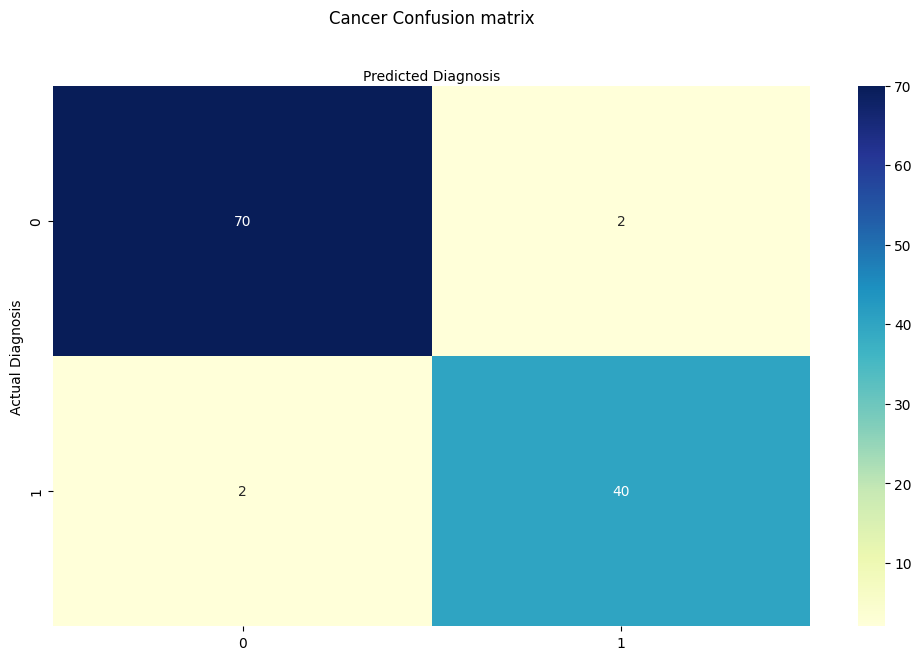

In [706]:
#Let's visualize the results of the model in the form of a co#nfusion matrix using matplotlib
#Here, you will visualize the confusion matrix using Heatmap.
import seaborn as sns
class_names_Cancer_Penalty=['Benign','Malignant'] # name  of classes 0---> Benign, 1---> Malignant

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names_Cancer_Penalty))
plt.xticks(tick_marks, class_names_Cancer_Penalty)
plt.yticks(tick_marks, class_names_Cancer_Penalty)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_Penalty), annot=True, cmap="YlGnBu" ,fmt='g')

ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Cancer Confusion matrix', y=1.1)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')